In [1]:
import pathlib

import numpy as np
import pandas as pd

In [2]:
from trait_prediction.main import PhenotypeSet, PhenotypeIndex
from trait_prediction.utils import (
    read_interpro_features,
    read_rast_features,
)

## Reading the data


In [3]:
data_folder = pathlib.Path("../data/raw/")

metabolic_phenotype_file = data_folder / "metabolic_phenotypes_bacdive.tsv"
non_metabolic_phenotype_file = data_folder / "non_metabolic_phenotypes_bacdive.tsv"
rast_feature_file = data_folder / "rast_features.tsv"
interpro_feature_file = data_folder / "interpro_features.tsv"

In [4]:
metabolic_phenotypeset = PhenotypeSet.read_data(str(metabolic_phenotype_file))
non_metabolic_phenotypeset = PhenotypeSet.read_data(str(non_metabolic_phenotype_file))

In [5]:
rast_features, rast_sso_dict = read_rast_features(rast_feature_file)
interpro_features, interpro_ipr_dict = read_interpro_features(interpro_feature_file)

In [6]:
tryptophan_index = PhenotypeIndex(name="tryptophan", category="energy_source")
tryptophan_phenotype = metabolic_phenotypeset[tryptophan_index]
tryptophan_phenotype.set_feature_data(rast_features, "rast")

In [7]:
tryptophan_phenotype

Phenotype (name=tryptophan, category=energy_source, size=2400)

## Machine learning using the RAST annotations


In [8]:
from collections import Counter

counter = Counter(tryptophan_phenotype.phenotype_data)
counter

Counter({0: 2141, 1: 259})

In [9]:
low_var_features, correlated_features_dict = tryptophan_phenotype.filter_feature_data(
    variance_threshold=0.05, correlation_treshold=0.95
)

In [10]:
from catboost import CatBoostClassifier

In [11]:
random_state = 42

In [12]:
categorical_feature_names = tryptophan_phenotype.feature_data.columns.tolist()

In [13]:
clf = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    random_state=random_state,
    loss_function="Logloss",
    cat_features=categorical_feature_names,
    verbose=False,
)

In [14]:
from trait_prediction.training import PhenotypePredictor

In [15]:
phenotype_predictor = PhenotypePredictor(
    tryptophan_phenotype, clf, random_state=random_state
)

In [16]:
set(phenotype_predictor._y.index) - set(phenotype_predictor._X.index)

set()

In [18]:
data = phenotype_predictor.split_data(test_size=0.3, stratify=True, imbalanced="auto")

In [19]:
phenotype_predictor.fit()

In [20]:
y_pred = phenotype_predictor.predict()

In [21]:
y_true = data["y_test"]

In [22]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [23]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97       642
           1       0.66      0.91      0.77        78

    accuracy                           0.94       720
   macro avg       0.83      0.93      0.87       720
weighted avg       0.95      0.94      0.94       720



In [24]:
balanced_accuracy_score(y_true, y_pred)

0.9270908219506351

In [25]:
# FIXME: You cannot use cv when using oversampling!
phenotype_predictor._y_train.value_counts()

tryptophan--energy_source
0    181
1    181
Name: count, dtype: int64

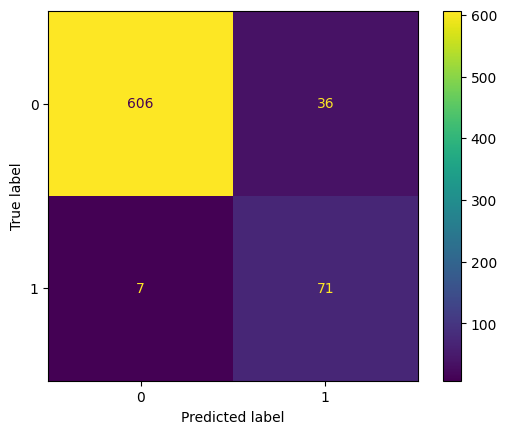

In [26]:
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()

In [27]:
cv_scores, estimators = phenotype_predictor.cross_validate_kfold(n_splits=5)

<Axes: xlabel='score', ylabel='metric'>

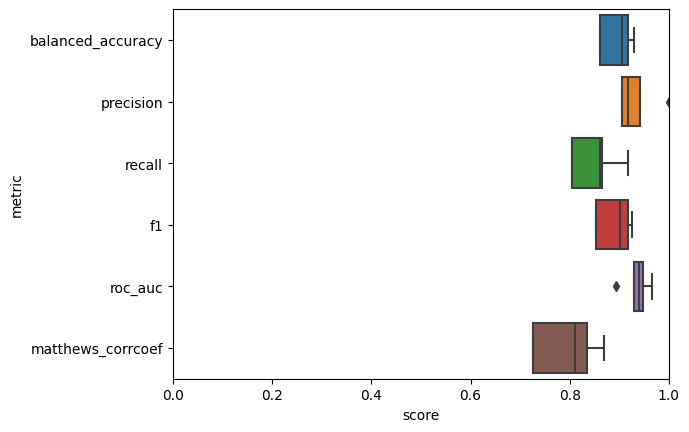

In [29]:
phenotype_predictor.plot_cross_validation(cv_scores)

## SHAP values


In [30]:
import shap

In [31]:
explainer = shap.Explainer(clf)

In [32]:
shap_values = explainer(tryptophan_phenotype.feature_data)

In [34]:
# shap.plots.waterfall(shap_values[0])

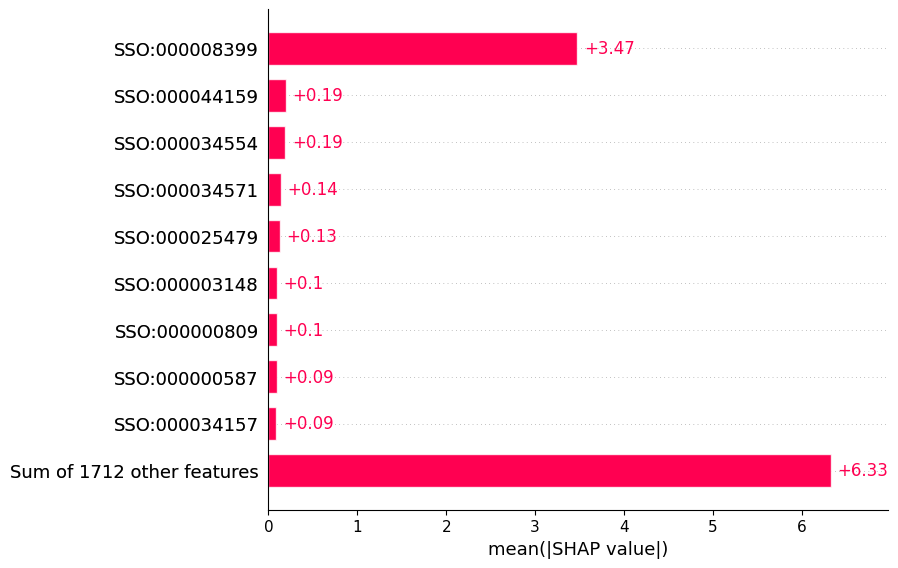

In [35]:
shap.plots.bar(shap_values)

In [36]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

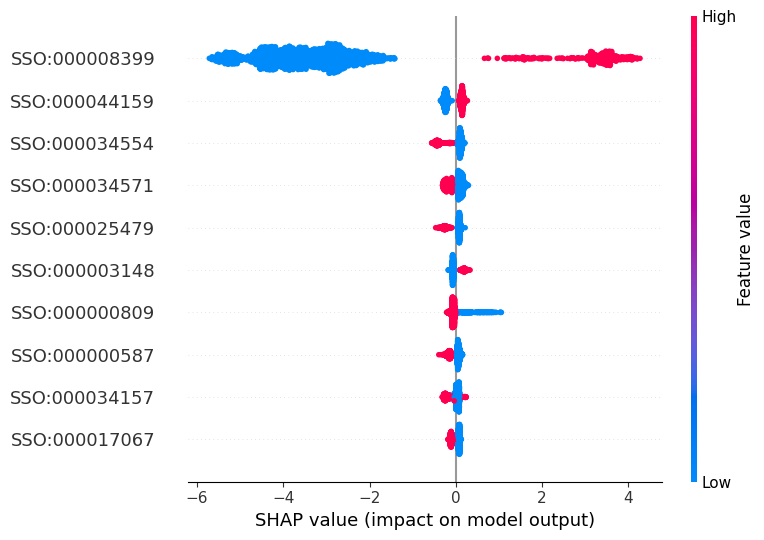

In [37]:
shap.summary_plot(shap_values, max_display=10, show=False)

In [40]:
rast_sso_dict["SSO:000008399"]

'Tryptophanase (EC 4.1.99.1)'